In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\fintech-review-analytics')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style='whitegrid')
print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('data/raw/reviews_with_sentiment.csv')
df['date'] = pd.to_datetime(df['date'])
print(f"Loaded {len(df):,} reviews")
print(f"Banks: {df['bank'].unique()}")
df.head()

Loaded 1,797 reviews
Banks: <ArrowStringArray>
['CBE', 'BOA', 'Dashen']
Length: 3, dtype: str


,review_id,review,rating,date,bank,source,sentiment_score,sentiment_label,identified_theme
0,1,pels,5,2026-05-18,CBE,Google Play,0.0000,Neutral,General Feedback
1,2,What an excellent app with smooth performance !!,5,2026-05-18,CBE,Google Play,0.6467,Positive,UI & App Design
2,3,በጣም ጥሩ ነው እነማሰግነለን,5,2026-05-18,CBE,Google Play,0.0000,Neutral,General Feedback
3,4,svabst keessatti argamu yoo ta'u yeroo ammaa k...,5,2026-05-18,CBE,Google Play,0.0000,Neutral,General Feedback
4,5,nays,5,2026-05-17,CBE,Google Play,0.0000,Neutral,General Feedback


## Task 4: Insights & Recommendations
### Business Context
Omega Consultancy is advising three Ethiopian banks on how to improve 
their mobile apps based on 1,797 Google Play Store reviews.

Banks: CBE (avg 4.10★), Dashen (avg 3.93★), BOA (avg 3.52★)

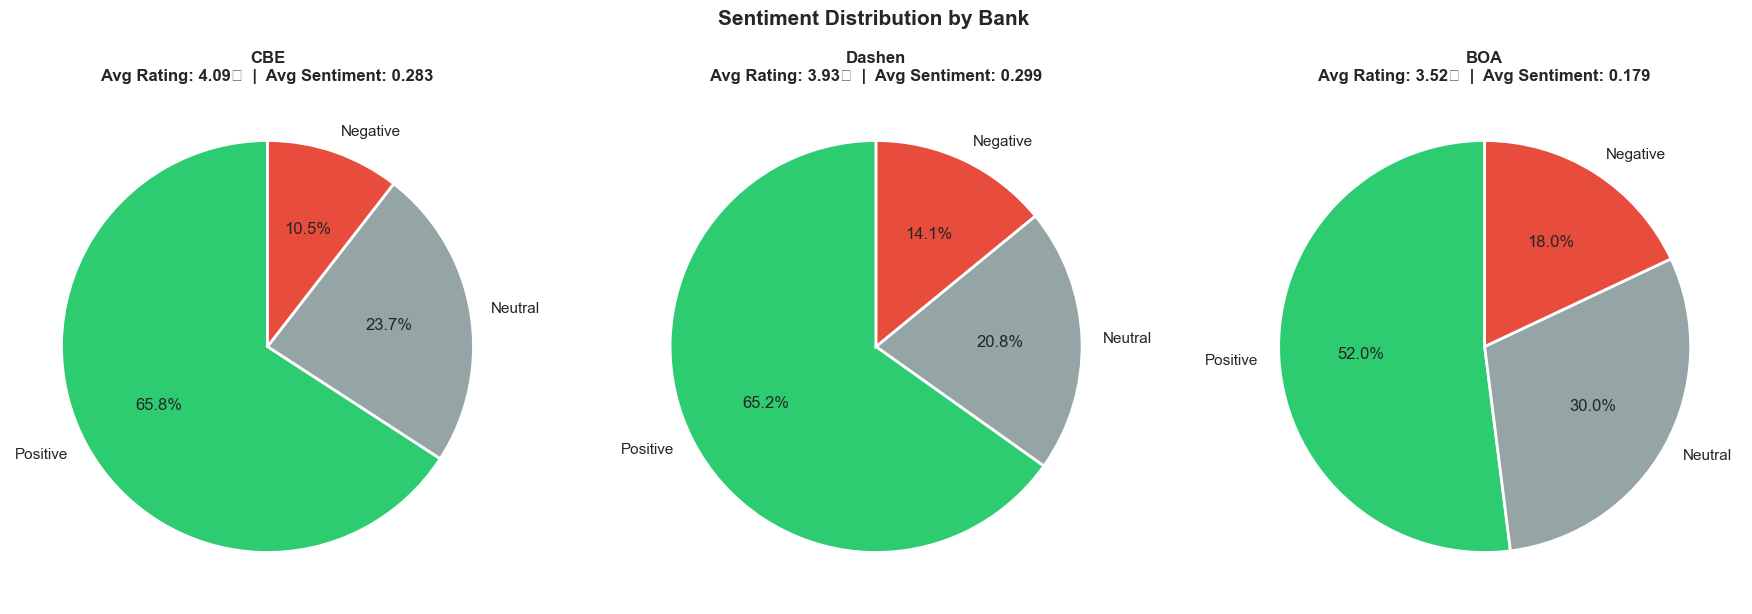

Plot 1 saved!


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

banks = ['CBE', 'Dashen', 'BOA']
colors = {'Positive':'#2ecc71', 'Neutral':'#95a5a6', 'Negative':'#e74c3c'}
bank_colors = {'CBE':'#3498db', 'BOA':'#e74c3c', 'Dashen':'#2ecc71'}

for i, bank in enumerate(banks):
    bank_df = df[df['bank'] == bank]
    counts = bank_df['sentiment_label'].value_counts()
    total = len(bank_df)
    
    wedge_colors = [colors.get(l, '#95a5a6') for l in counts.index]
    axes[i].pie(counts.values, labels=counts.index,
                autopct='%1.1f%%', colors=wedge_colors,
                startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
    
    avg_rating = bank_df['rating'].mean()
    avg_sent = bank_df['sentiment_score'].mean()
    axes[i].set_title(f'{bank}\nAvg Rating: {avg_rating:.2f}★  |  Avg Sentiment: {avg_sent:.3f}',
                      fontsize=12, fontweight='bold')

plt.suptitle('Sentiment Distribution by Bank', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/plot1_sentiment_pie.png', dpi=150)
plt.show()
print("Plot 1 saved!")

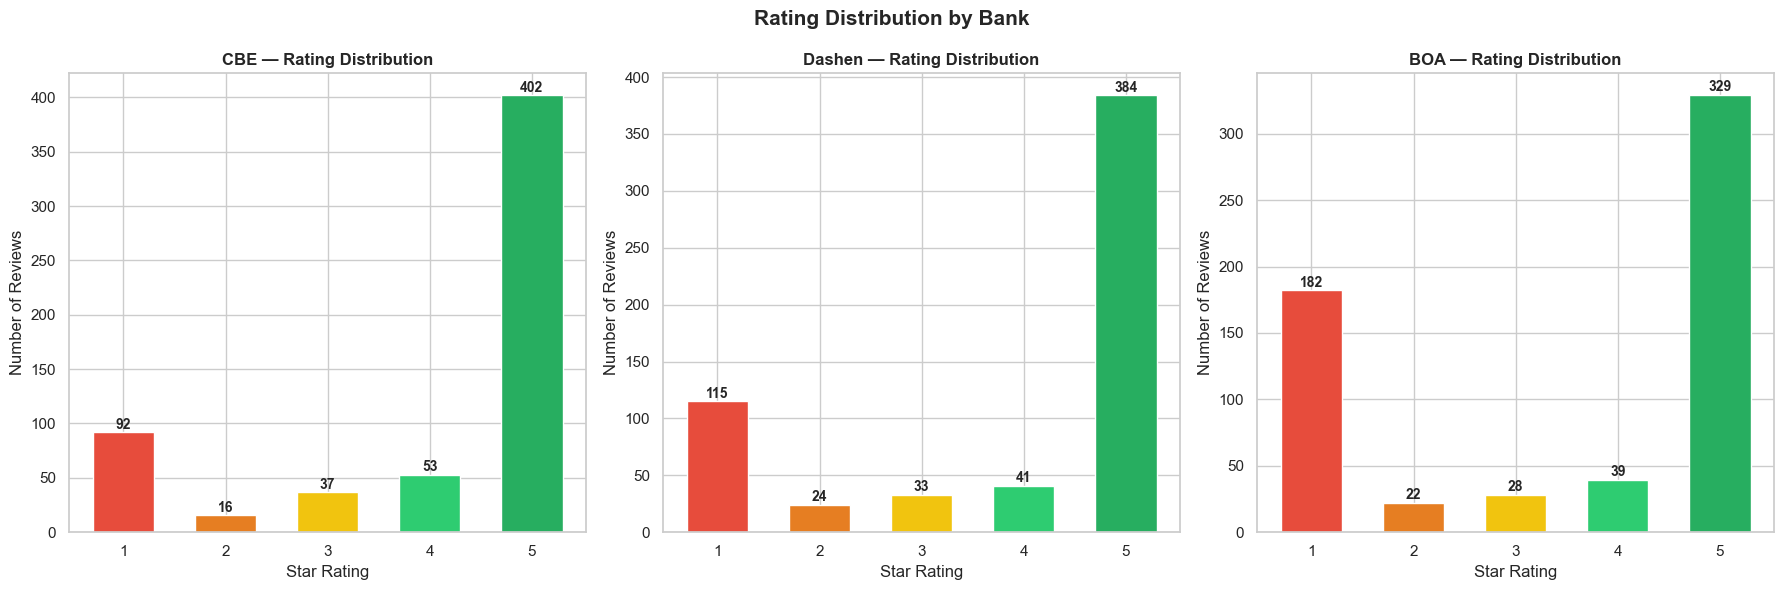

Plot 2 saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

rating_colors = {1:'#e74c3c', 2:'#e67e22', 3:'#f1c40f', 4:'#2ecc71', 5:'#27ae60'}

for i, bank in enumerate(banks):
    bank_df = df[df['bank'] == bank]
    rating_counts = bank_df['rating'].value_counts().sort_index()
    
    bar_colors = [rating_colors[r] for r in rating_counts.index]
    bars = axes[i].bar(rating_counts.index, rating_counts.values,
                       color=bar_colors, edgecolor='white', width=0.6)
    
    for bar, val in zip(bars, rating_counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 3,
                     str(val), ha='center', fontweight='bold', fontsize=10)
    
    axes[i].set_title(f'{bank} — Rating Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Star Rating')
    axes[i].set_ylabel('Number of Reviews')
    axes[i].set_xticks([1,2,3,4,5])

plt.suptitle('Rating Distribution by Bank', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot2_rating_distribution.png', dpi=150)
plt.show()
print("Plot 2 saved!")

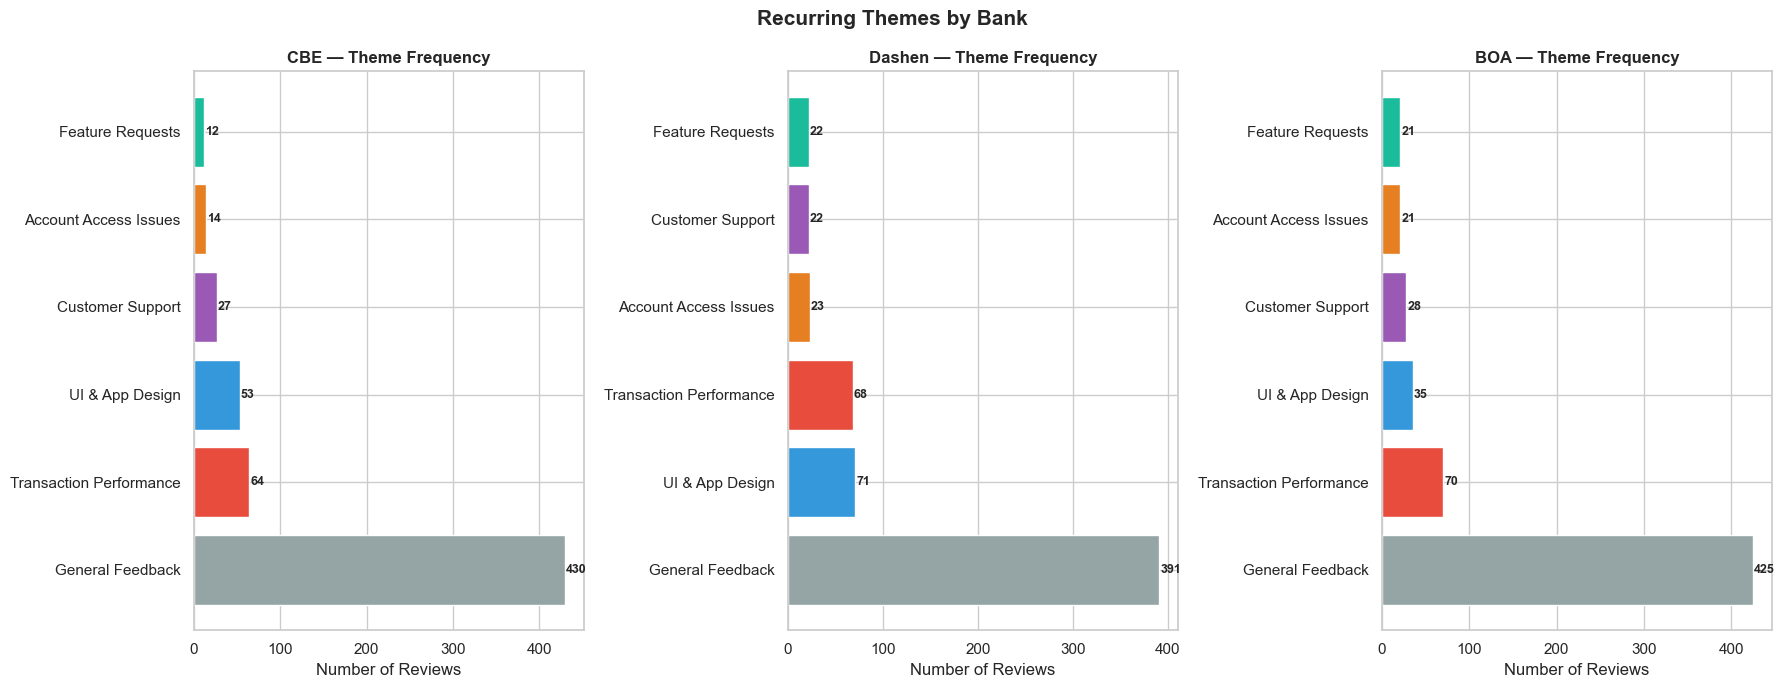

Plot 3 saved!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

theme_colors = {
    'Transaction Performance': '#e74c3c',
    'Account Access Issues':   '#e67e22',
    'UI & App Design':         '#3498db',
    'Customer Support':        '#9b59b6',
    'Feature Requests':        '#1abc9c',
    'General Feedback':        '#95a5a6'
}

for i, bank in enumerate(banks):
    bank_df = df[df['bank'] == bank]
    theme_counts = bank_df['identified_theme'].value_counts()
    
    colors_list = [theme_colors.get(t, '#95a5a6') for t in theme_counts.index]
    bars = axes[i].barh(theme_counts.index, theme_counts.values,
                        color=colors_list, edgecolor='white')
    
    for bar, val in zip(bars, theme_counts.values):
        axes[i].text(val + 1, bar.get_y() + bar.get_height()/2,
                     str(val), va='center', fontsize=9, fontweight='bold')
    
    axes[i].set_title(f'{bank} — Theme Frequency', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Number of Reviews')

plt.suptitle('Recurring Themes by Bank', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot3_theme_frequency.png', dpi=150)
plt.show()
print("Plot 3 saved!")

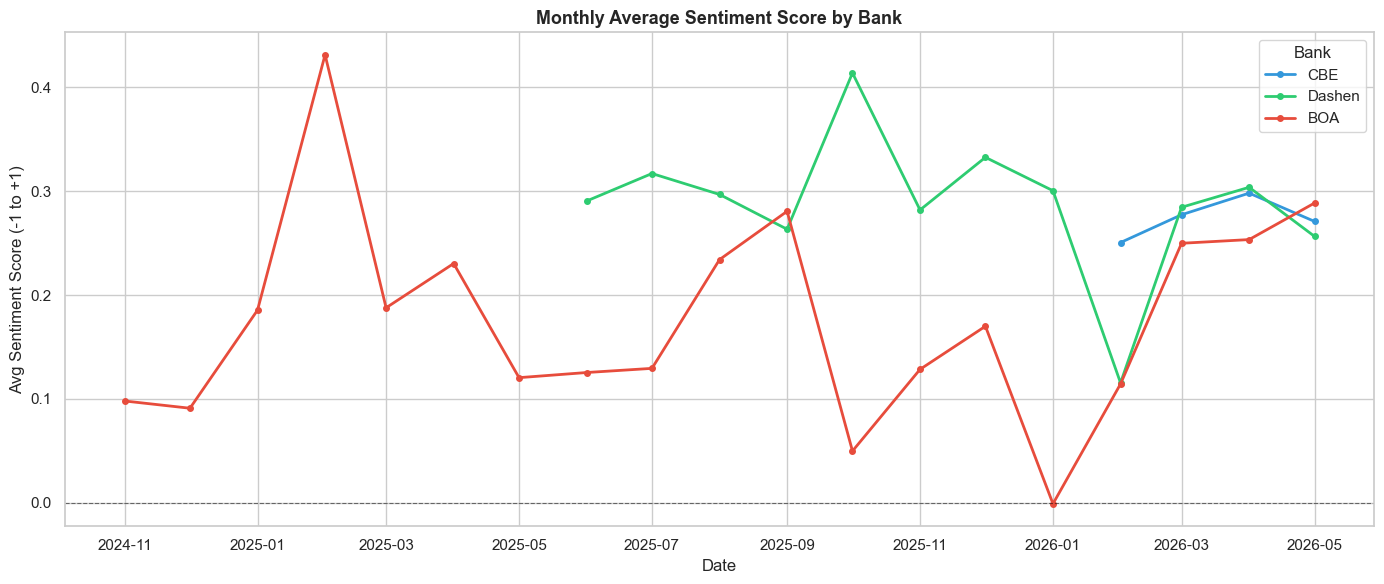

Plot 4 saved!


In [6]:
df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby(['bank','month'])['sentiment_score'].mean().reset_index()
monthly['month'] = monthly['month'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
for bank in banks:
    data = monthly[monthly['bank'] == bank]
    plt.plot(data['month'], data['sentiment_score'],
             label=bank, color=bank_colors[bank],
             linewidth=2, marker='o', markersize=4)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('Monthly Average Sentiment Score by Bank', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Avg Sentiment Score (-1 to +1)')
plt.legend(title='Bank', fontsize=11)
plt.tight_layout()
plt.savefig('notebooks/plot4_sentiment_over_time.png', dpi=150)
plt.show()
print("Plot 4 saved!")

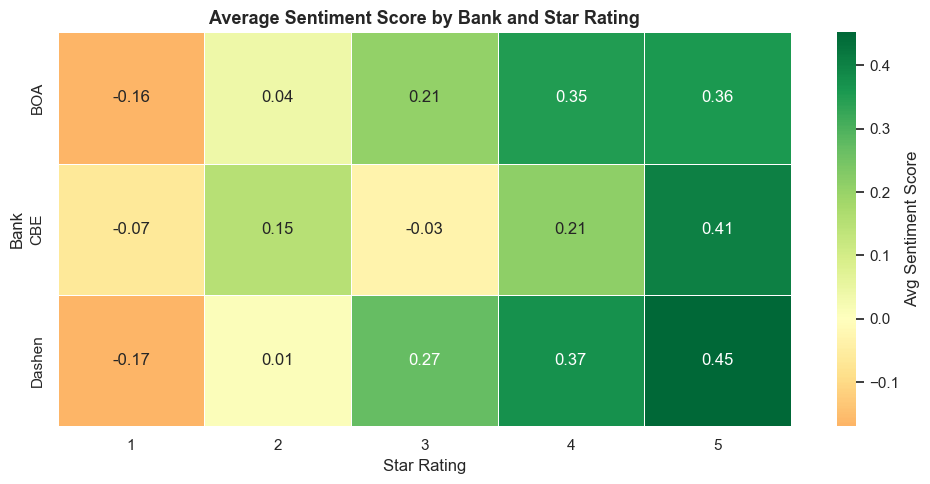

Plot 5 saved!


In [7]:
pivot = df.groupby(['bank','rating'])['sentiment_score'].mean().unstack()

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5,
            cbar_kws={'label': 'Avg Sentiment Score'})
plt.title('Average Sentiment Score by Bank and Star Rating', fontsize=13, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Bank')
plt.tight_layout()
plt.savefig('notebooks/plot5_sentiment_rating_heatmap.png', dpi=150)
plt.show()
print("Plot 5 saved!")

In [8]:
print("=" * 60)
print("KEY INSIGHTS FROM DATA ANALYSIS")
print("=" * 60)

for bank in banks:
    bank_df = df[df['bank'] == bank]
    
    print(f"\n{'─'*40}")
    print(f"  {bank}")
    print(f"{'─'*40}")
    
    # Ratings
    avg_rating = bank_df['rating'].mean()
    pct_5star = (bank_df['rating'] == 5).mean() * 100
    pct_1star = (bank_df['rating'] == 1).mean() * 100
    
    # Sentiment
    avg_sent = bank_df['sentiment_score'].mean()
    pct_positive = (bank_df['sentiment_label'] == 'Positive').mean() * 100
    pct_negative = (bank_df['sentiment_label'] == 'Negative').mean() * 100
    
    # Top theme (excluding General Feedback)
    specific = bank_df[bank_df['identified_theme'] != 'General Feedback']
    top_theme = specific['identified_theme'].value_counts().index[0] if len(specific) > 0 else 'N/A'
    
    # Top positive keywords
    pos_reviews = bank_df[bank_df['sentiment_label'] == 'Positive']['review']
    neg_reviews = bank_df[bank_df['sentiment_label'] == 'Negative']['review']
    
    print(f"  Avg Rating:     {avg_rating:.2f} ★")
    print(f"  5-star reviews: {pct_5star:.1f}%")
    print(f"  1-star reviews: {pct_1star:.1f}%")
    print(f"  Avg Sentiment:  {avg_sent:.3f}")
    print(f"  Positive:       {pct_positive:.1f}%")
    print(f"  Negative:       {pct_negative:.1f}%")
    print(f"  Top Issue:      {top_theme}")
    print(f"  Positive count: {len(pos_reviews)}")
    print(f"  Negative count: {len(neg_reviews)}")

KEY INSIGHTS FROM DATA ANALYSIS

────────────────────────────────────────
  CBE
────────────────────────────────────────
  Avg Rating:     4.09 ★
  5-star reviews: 67.0%
  1-star reviews: 15.3%
  Avg Sentiment:  0.283
  Positive:       65.8%
  Negative:       10.5%
  Top Issue:      Transaction Performance
  Positive count: 395
  Negative count: 63

────────────────────────────────────────
  Dashen
────────────────────────────────────────
  Avg Rating:     3.93 ★
  5-star reviews: 64.3%
  1-star reviews: 19.3%
  Avg Sentiment:  0.299
  Positive:       65.2%
  Negative:       14.1%
  Top Issue:      UI & App Design
  Positive count: 389
  Negative count: 84

────────────────────────────────────────
  BOA
────────────────────────────────────────
  Avg Rating:     3.52 ★
  5-star reviews: 54.8%
  1-star reviews: 30.3%
  Avg Sentiment:  0.179
  Positive:       52.0%
  Negative:       18.0%
  Top Issue:      Transaction Performance
  Positive count: 312
  Negative count: 108


In [9]:
print("=== SAMPLE POSITIVE REVIEWS ===\n")
for bank in banks:
    pos = df[(df['bank']==bank) & (df['sentiment_label']=='Positive')]['review']
    print(f"--- {bank} ---")
    for r in pos.head(3).values:
        print(f"  • {r[:120]}")
    print()

print("\n=== SAMPLE NEGATIVE REVIEWS ===\n")
for bank in banks:
    neg = df[(df['bank']==bank) & (df['sentiment_label']=='Negative')]['review']
    print(f"--- {bank} ---")
    for r in neg.head(3).values:
        print(f"  • {r[:120]}")
    print()

=== SAMPLE POSITIVE REVIEWS ===

--- CBE ---
  • What an excellent app with smooth performance !!
  • very very good 👍 thanks commercial bank of ethiopia 🤩😘💯
  • so nice

--- Dashen ---
  • It is a very cool application, but it requires a lot of network data. It also asks for updates too quickly, and it is no
  • excellent
  • good

--- BOA ---
  • was Good 🙏
  • cool
  • Its Good


=== SAMPLE NEGATIVE REVIEWS ===

--- CBE ---
  • Please make the CBE Noor toggle to be optional just because I have another account that happened to be CBE Noor it doesn
  • It stopped working on its own. When you check your balance it does not show the amount before deductions.
  • The most backward and unstable financial app in the market. It requires updates in which nothing changes, it is slow snd

--- Dashen ---
  • Misguiding - Claimed anyone can convert ETB to USD for online payments, but not true.
  • Very Annoying App i tried to open virtual bank account with fayda but in the end it says something 

## Bank-Specific Insights & Recommendations

---

### CBE (Commercial Bank of Ethiopia)
**Avg Rating: 4.10★ | Sentiment: 0.283 (Most Positive)**

**Satisfaction Drivers:**
1. Reliable transfer functionality — users praise fast money transfers
2. Simple, clean UI — positive feedback on ease of navigation

**Pain Points:**
1. Transaction Performance — slow loading during peak hours reported
2. Account Access — occasional login and OTP failures frustrate users

**Recommendations:**
1. Invest in server capacity to handle peak-hour transaction loads
2. Implement biometric (fingerprint) login to reduce OTP dependency
3. Add in-app transaction status notifications to reduce anxiety during delays

---

### Dashen Bank
**Avg Rating: 3.93★ | Sentiment: 0.299 (Highest Sentiment)**

**Satisfaction Drivers:**
1. Modern UI praised as user-friendly and visually appealing
2. Diverse feature set appreciated by tech-savvy users

**Pain Points:**
1. UI & App Design — users request more consistent design updates
2. Account Access — fingerprint login issues and password reset failures

**Recommendations:**
1. Prioritize fingerprint/biometric login reliability
2. Add budgeting and spending analytics features to differentiate from competitors
3. Implement dark mode and accessibility features requested by users

---

### BOA (Bank of Abyssinia)
**Avg Rating: 3.52★ | Sentiment: 0.179 (Most Negative)**

**Satisfaction Drivers:**
1. Basic transfer functionality works for most users
2. Some users appreciate customer support responsiveness

**Pain Points:**
1. Transaction Performance — highest complaint rate about failed/slow transfers
2. Customer Support — users report slow response times and unresolved issues

**Recommendations:**
1. URGENT: Fix transaction failure bugs — this is the #1 driver of 1-star reviews
2. Introduce AI chatbot for 24/7 basic support queries (OTP reset, balance inquiry)
3. Implement push notifications for transaction confirmations to build user trust

## Ethical Considerations & Limitations

1. **Negativity Bias**: Users are more likely to leave reviews after bad experiences,
   which may overrepresent negative sentiment relative to the actual user base.

2. **Sampling Bias**: Reviews are limited to English-language Google Play Store users,
   excluding Amharic-speaking users who may have different experiences.

3. **Date Limitation**: Reviews scraped represent the most recent period only,
   which may not reflect the full historical performance of each app.

4. **VADER Limitations**: VADER was designed for social media English and may
   misclassify Ethiopian English expressions or transliterated Amharic text.

5. **Theme Assignment**: Keyword-based theme assignment is a simplification;
   a single review may address multiple themes simultaneously.

In [10]:
print("Task 4 Complete!")
print("\nPlots saved:")
plots = [
    'plot1_sentiment_pie.png',
    'plot2_rating_distribution.png', 
    'plot3_theme_frequency.png',
    'plot4_sentiment_over_time.png',
    'plot5_sentiment_rating_heatmap.png'
]
for p in plots:
    path = f'notebooks/{p}'
    exists = os.path.exists(path)
    print(f"  {'✅' if exists else '❌'} {p}")

Task 4 Complete!

Plots saved:
  ✅ plot1_sentiment_pie.png
  ✅ plot2_rating_distribution.png
  ✅ plot3_theme_frequency.png
  ✅ plot4_sentiment_over_time.png
  ✅ plot5_sentiment_rating_heatmap.png
